In [17]:
from sensor_network_utils import * 
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load data
flowdata_paths = ['data/dailyflow_v3_1.csv', 'data/dailyflow_v3_2.csv']
df_cleaned, gauges_gdf, flowlines_gdf, usgs_index_df = load_data(
    flowdata_paths,
    'data/gage_12_shpaefile/SWIM_gage_loc_12.shp',
    'data/tx_gulf_flowlines/flowlines.shp',
    'data/gage_12.csv'
)

In [5]:
# Prepare USGS indices
usgs_location, usgs_number, columns_to_keep = prepare_usgs_indices(df_cleaned, usgs_index_df)


In [6]:
# Split data
X_train, X_test = split_data(df_cleaned.values)


Calculating flowline risk scores...
Figure saved to flood_risk_map_clipped.png


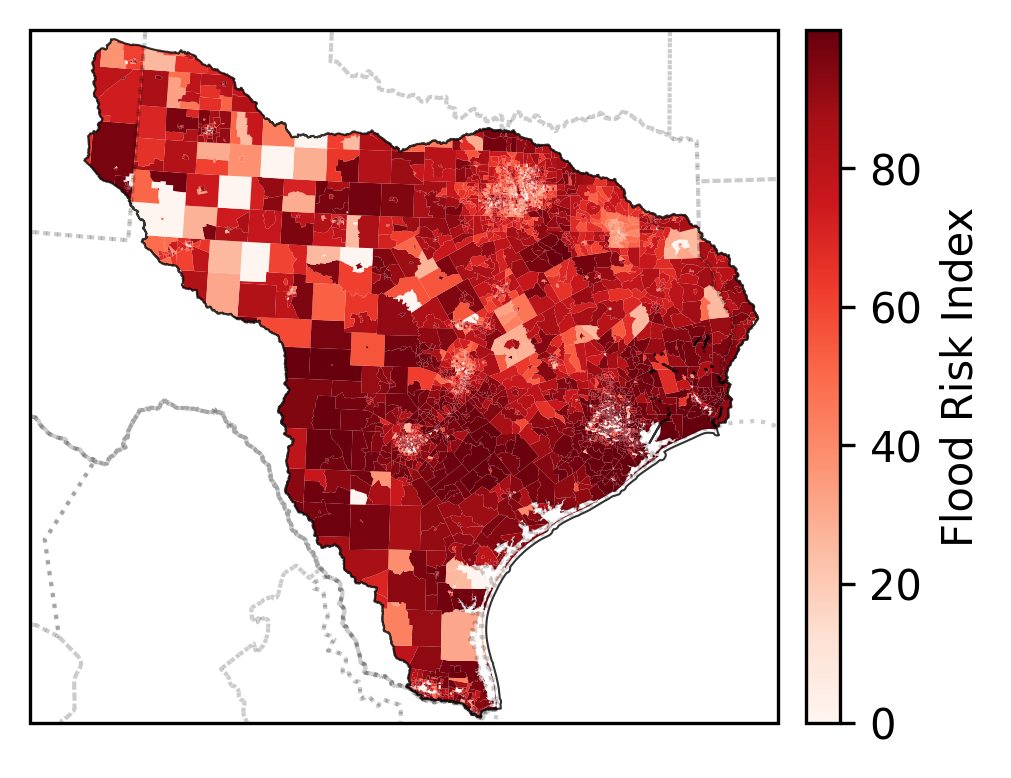

In [7]:
gdb_path = "data/NRI_GDB_CensusTracts/NRI_GDB_CensusTracts.gdb"
huc2_texas_path = "data/huc2_12_boundary/HU02_12.shp"
huc2_texas_gdf = gpd.read_file(huc2_texas_path)

fig, ax, flowlines_risk, flood_risk = plot_flood_risk_map_clipped(
    gdb_path=gdb_path,
    flowlines_gdf=flowlines_gdf,
    df_cleaned=df_cleaned,
    huc2_boundary_gdf=huc2_texas_gdf,
    save_path='flood_risk_map_clipped.png'
)

In [8]:
# Get sensor placement 
sensor_location = sensor_placement_qr(X_train, usgs_number)
sensor_location_risk = sensor_placement_qr(X_train, usgs_number, weights = flood_risk)

In [9]:
# Evaluate both configurations
_, recon_opt, _, _, rmse_values_opt, _ = reconstruction_evaluation(X_train, X_test, sensor_location, usgs_number)
_, recon_usgs, _, _, rmse_values_usgs, _ = reconstruction_evaluation(X_train, X_test, usgs_location, usgs_number)
_, recon_risk, _, _, rmse_values_risk, _ = reconstruction_evaluation(X_train, X_test, sensor_location_risk, usgs_number)

In [10]:
# Calculate performance

_, _, nnse_opt = calculate_performance_metrics(X_test, recon_opt)
_, _, nnse_usgs = calculate_performance_metrics(X_test, recon_usgs)
_, _, nnse_risk = calculate_performance_metrics(X_test, recon_risk)
diff_nnse = nnse_opt - nnse_risk

In [19]:
# Visualization

flowlines_with_nnse, centroids = prepare_visualization_data(
    flowlines_gdf, 
    df_cleaned, 
    diff_nnse,
    {'risk': sensor_location_risk, 'opt': sensor_location},
    usgs_number
)

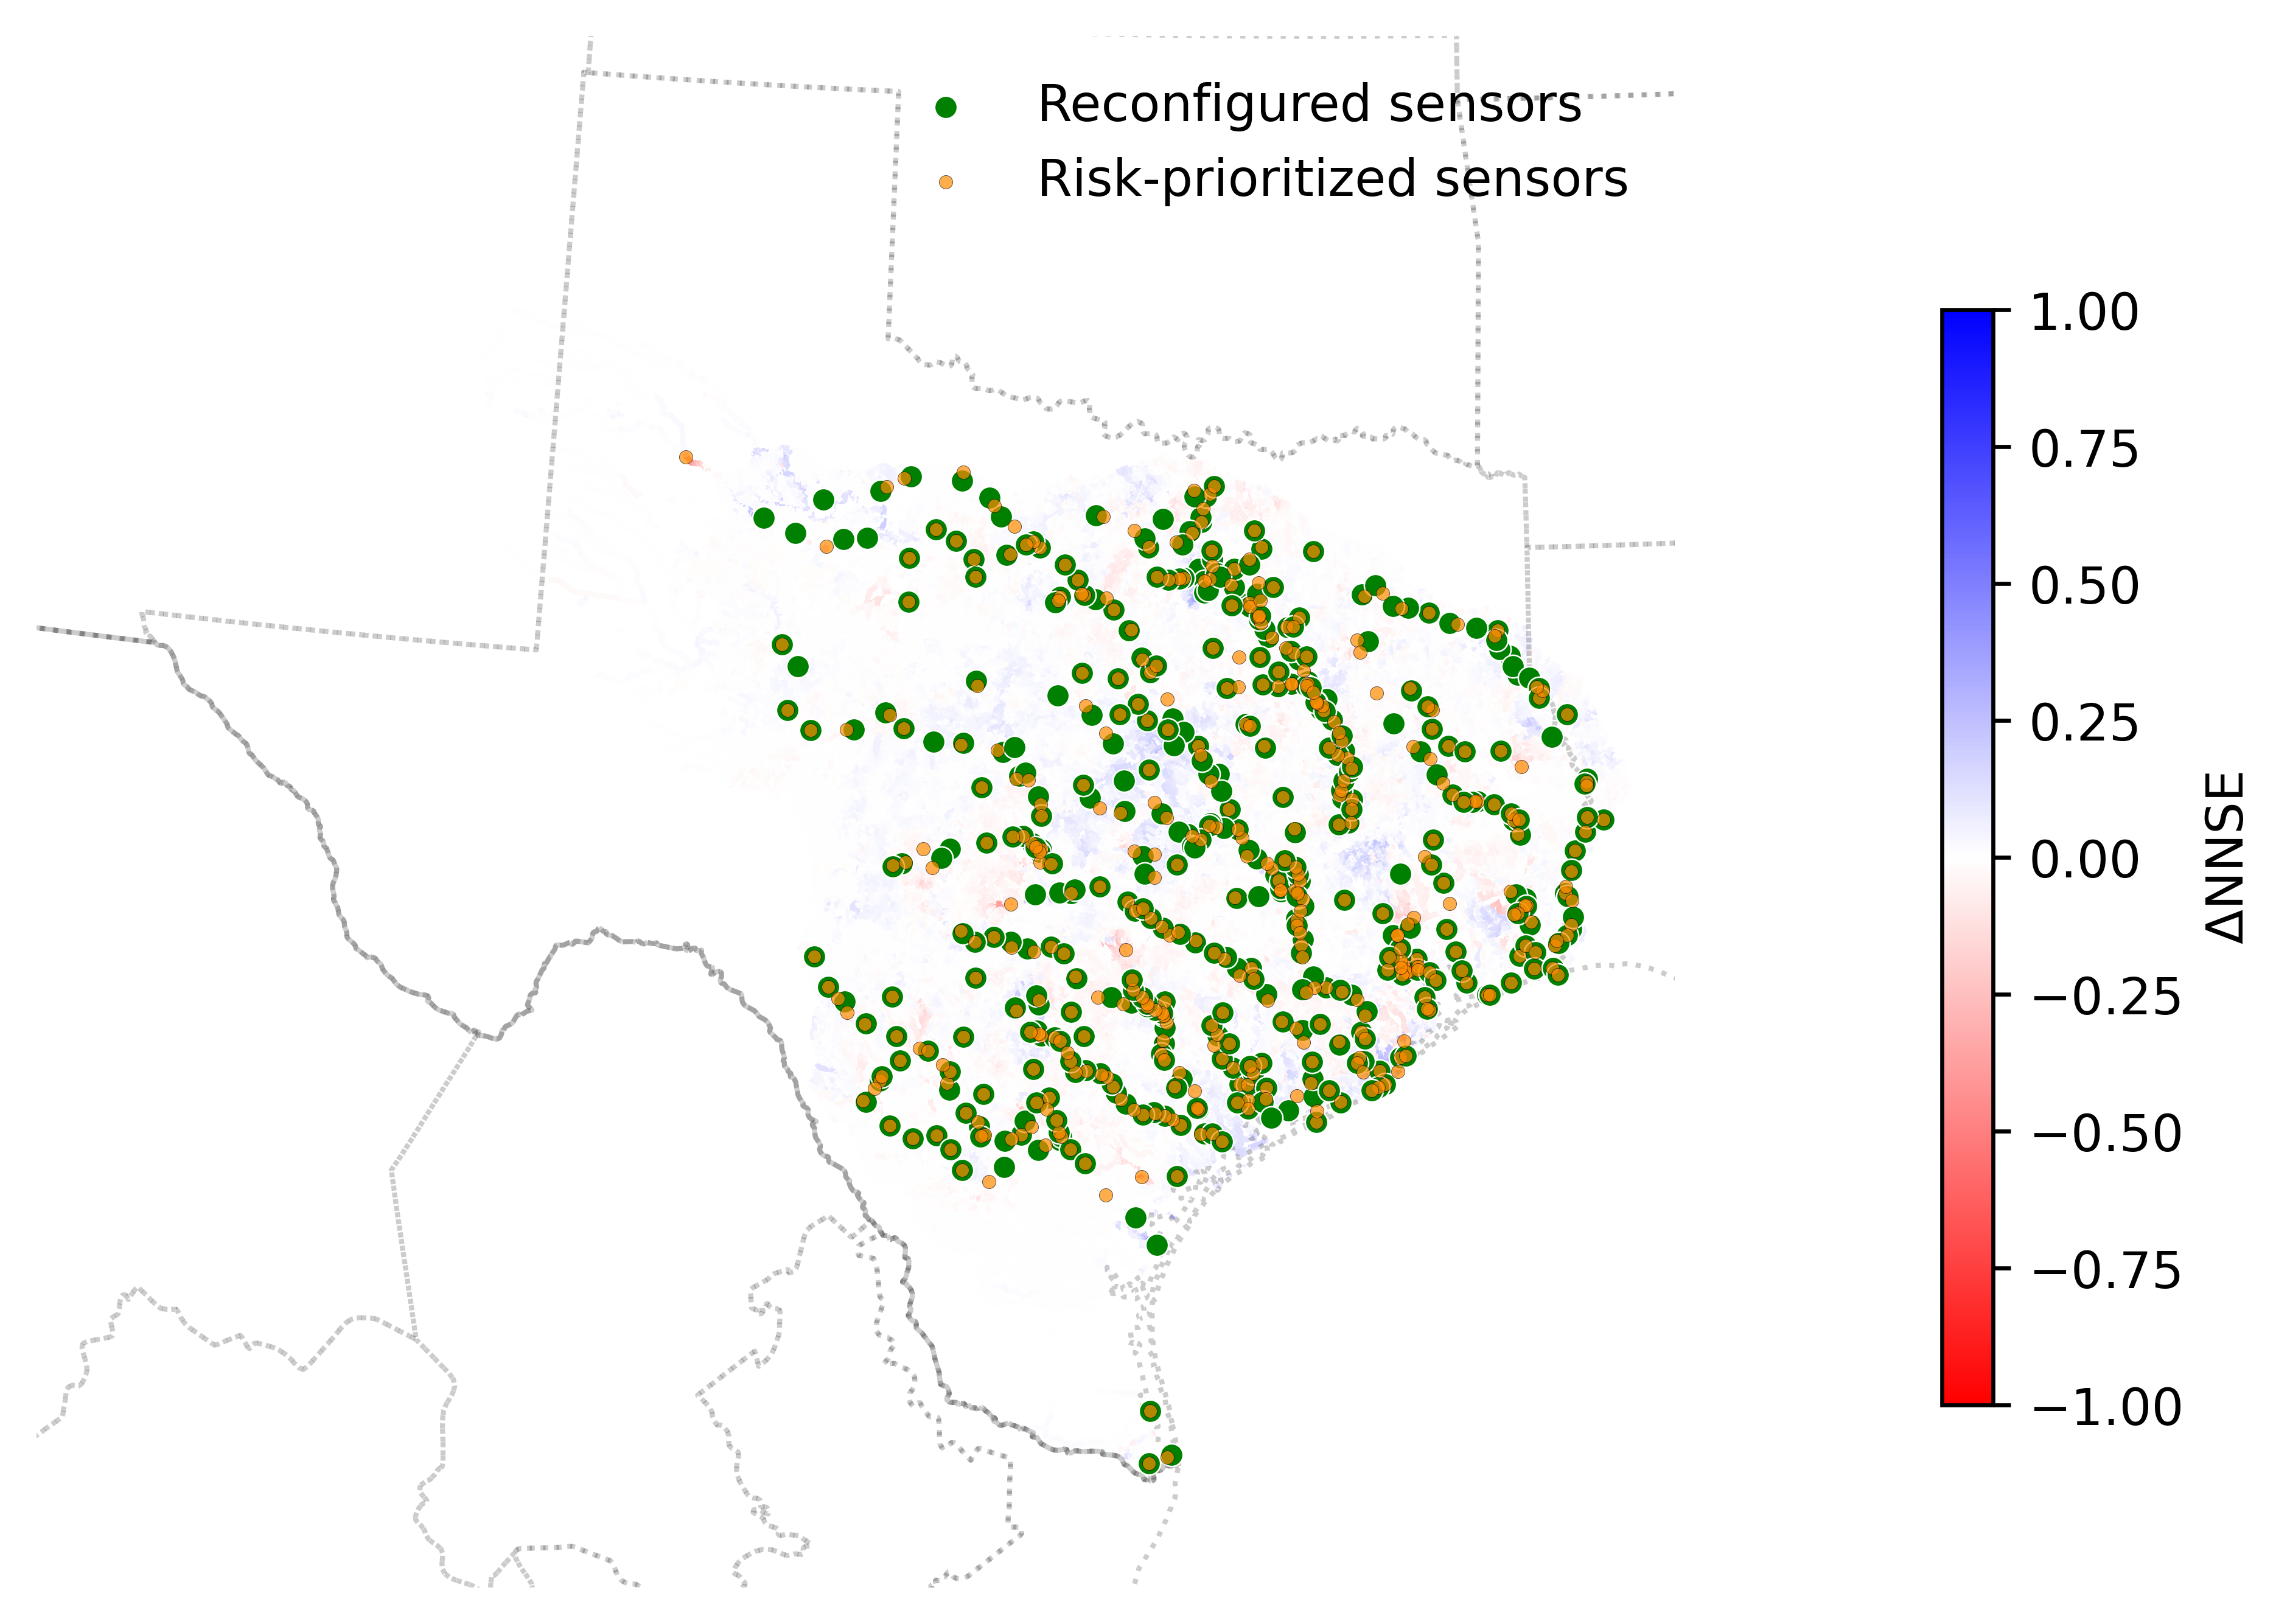

In [21]:
proj = ccrs.LambertConformal(central_latitude=33, central_longitude=-96, 
                                standard_parallels=(33.0, 45.0))
flowlines_gdf_with_rmse = flowlines_with_nnse.to_crs(proj.proj4_params)
centroids = {k: v.to_crs(proj.proj4_params) for k, v in centroids.items()}

fig, ax = plt.subplots(figsize=(7, 5), dpi=600, subplot_kw={'projection': proj})
ax.set_extent([-106.65, -93.0, 25.0, 36.5], crs=ccrs.PlateCarree())
ax.spines['geo'].set_visible(False)

lines = LineCollection([np.array(geometry.xy).T for geometry in flowlines_gdf_with_rmse.geometry],
                        linewidths=1, alpha=1, zorder=1)
norm = Normalize(vmin=-1, vmax=1)
lines.set_array(flowlines_gdf_with_rmse['RMSE'])
lines.set_cmap('bwr_r')
lines.set_norm(norm)
ax.add_collection(lines)

cb_ax = fig.add_axes([0.85, 0.2, 0.02, 0.6])
cb = fig.colorbar(lines, cax=cb_ax, orientation='vertical', label=r'$\Delta \mathrm{NNSE}$')

scatter_props = {
    'usgs': {'color': 'k', 'label': 'USGS gauges'},
    'opt': {'color': 'green', 'label': 'Reconfigured sensors'},
    'risk': {'color': 'darkorange', 'label': 'Risk-weighted sensors'}
}


ax.scatter(centroids['opt'].geometry.x, centroids['opt'].geometry.y, 
            color='green', edgecolor='white', linewidths=0.3, alpha=1, s=20,
            label=f'Reconfigured sensors', zorder=3)


ax.scatter(centroids['risk'].geometry.x, centroids['risk'].geometry.y, 
            color='darkorange', edgecolor='k', linewidths=0.1, alpha=0.7, s=7,
            label=f'Risk-prioritized sensors', zorder=4)

# Add map features and legend
ax.add_feature(feature.BORDERS, linestyle='-', alpha=.2)
ax.add_feature(feature.STATES, linestyle=':', alpha=.2)
ax.legend(frameon=False, loc='best')

plt.subplots_adjust(left=0.05, right=0.8, top=0.95, bottom=0.1)
plt.show()

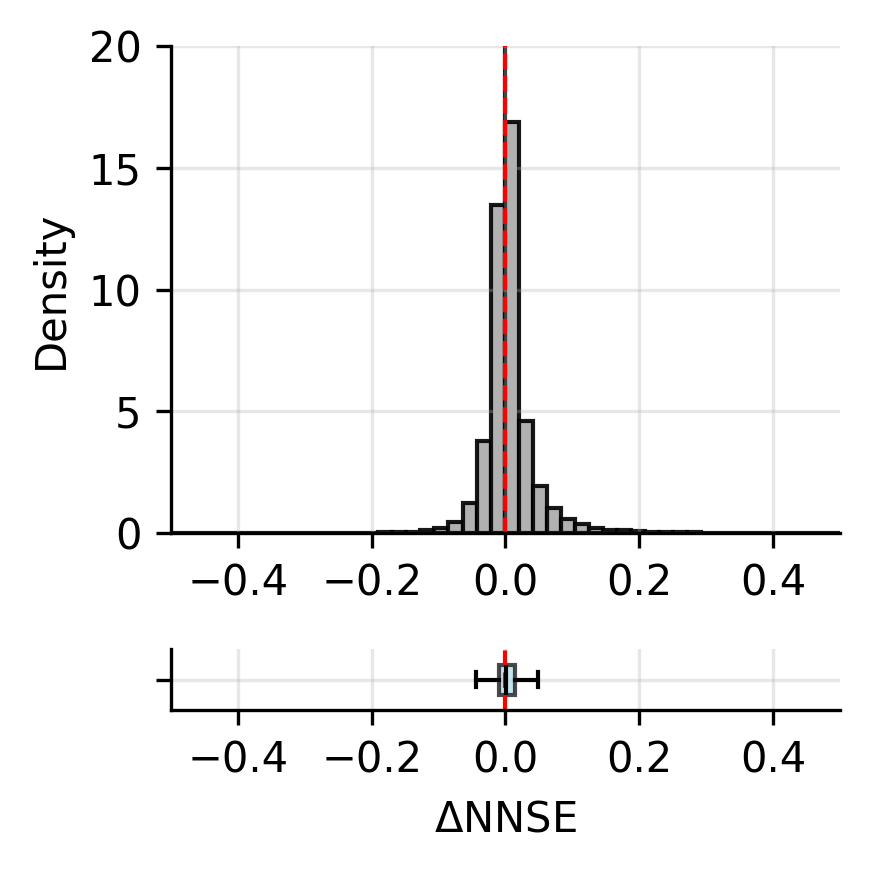

In [23]:
diff_nnse = np.array(diff_nnse)
diff_nnse_cleaned = diff_nnse[~np.isnan(diff_nnse)] 
bin_edges = np.histogram_bin_edges(diff_nnse_cleaned, bins=50)
bin_edges = np.unique(np.concatenate((bin_edges, [0])))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 3), gridspec_kw={'height_ratios': [2, 0.25]}, dpi = 300)

ax1.set_facecolor('none')
ax2.set_facecolor('none')

ax1.hist(diff_nnse_cleaned, bins=bin_edges, alpha=0.9, edgecolor='k', color='darkgrey', density=True)
ax1.set_ylabel('Density')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 20)
ax1.set_xlim(-0.5, 0.5)

bp = ax2.boxplot(diff_nnse_cleaned, patch_artist=True, vert=False, showfliers=False, widths=0.5)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)
bp['medians'][0].set_color('black')
bp['medians'][0].set_linewidth(1)

ax2.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel(r'$\Delta \mathrm{NNSE}$')
ax2.set_yticklabels([''])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.3)
ax2.set_xlim(ax1.get_xlim())

plt.gca().set_facecolor('none')
plt.gcf().patch.set_alpha(0) 

plt.tight_layout()
plt.show()

In [13]:
rmse_datasets = [
    ('USGS', rmse_values_usgs),
    ('QR', rmse_values_opt),
    ('QR with Flood Risk', rmse_values_risk)
]
labels, data = zip(*rmse_datasets)

In [14]:
# Normalize cost_index
scaler = MinMaxScaler()
epsilon = 1e-10

cost_index_normalized = scaler.fit_transform(flood_risk.reshape(-1, 1)).flatten()
cost_index_normalized = np.maximum(cost_index_normalized, epsilon)
cost_index = np.maximum(flood_risk, epsilon)

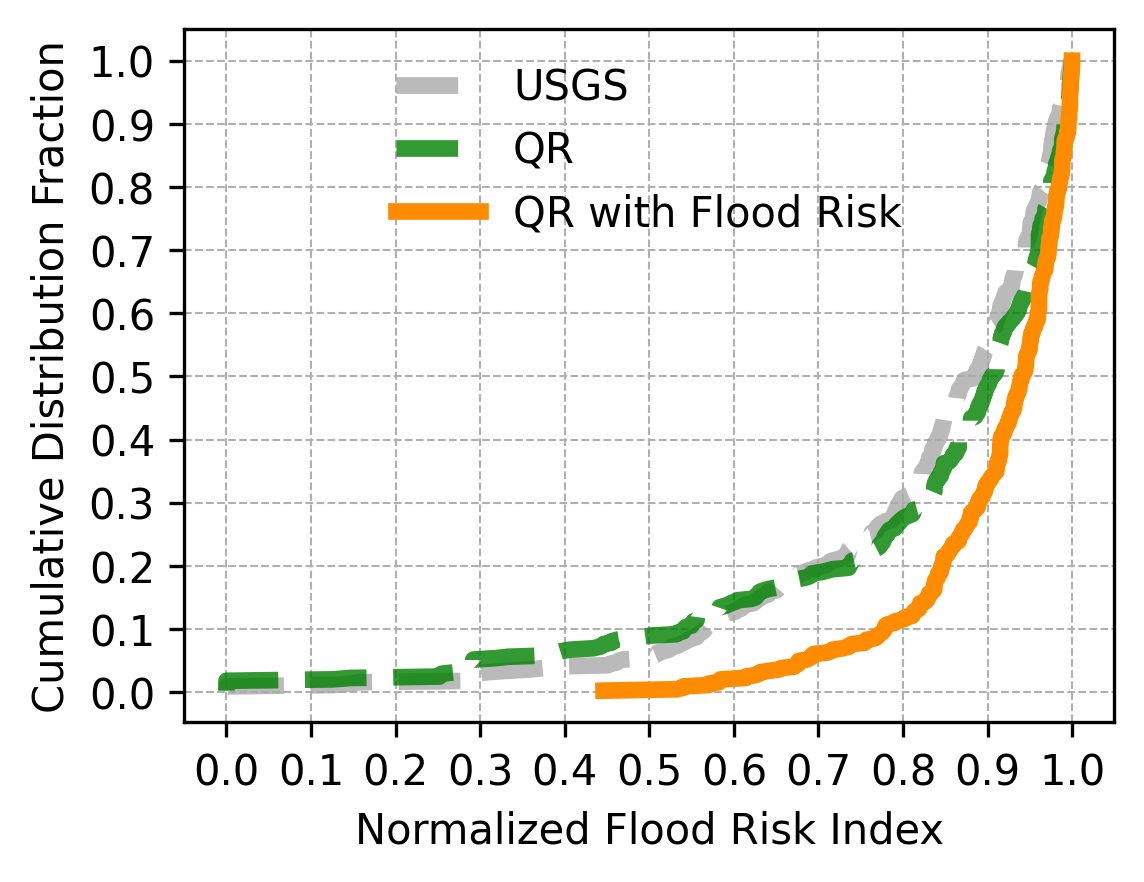

In [15]:
costs = np.sort(cost_index_normalized[sensor_location_risk]).reshape(-1, 1)
costs_usgs = np.sort(cost_index_normalized[usgs_location]).reshape(-1, 1)
costs_raw = np.sort(cost_index_normalized[sensor_location]).reshape(-1, 1)

cumulative = np.arange(1, len(costs) + 1) / len(costs)
cumulative_usgs = np.arange(1, len(costs_usgs)+1) / len(costs_usgs)
cumulative_raw = np.arange(1, len(costs_raw)+1) / len(costs_raw)
colors = ['darkgrey', 'green', 'darkorange']

plt.figure(figsize=(4, 3), dpi=300)  
plt.plot(costs_usgs, cumulative_usgs, linestyle='--', color=colors[0], alpha = 0.8, linewidth = 4, label='USGS')
plt.plot(costs_raw, cumulative_raw, linestyle='--', color=colors[1], alpha = 0.8, linewidth = 4, label='QR')
plt.plot(costs, cumulative, linestyle='-', color=colors[2], linewidth = 4, label='QR with Flood Risk')

plt.xlabel('Normalized Flood Risk Index')
plt.ylabel('Cumulative Distribution Fraction')

plt.xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
plt.legend(frameon=False, loc = 'upper center') 
plt.grid(True, which='both', linestyle='--', linewidth=0.5) 
plt.show()

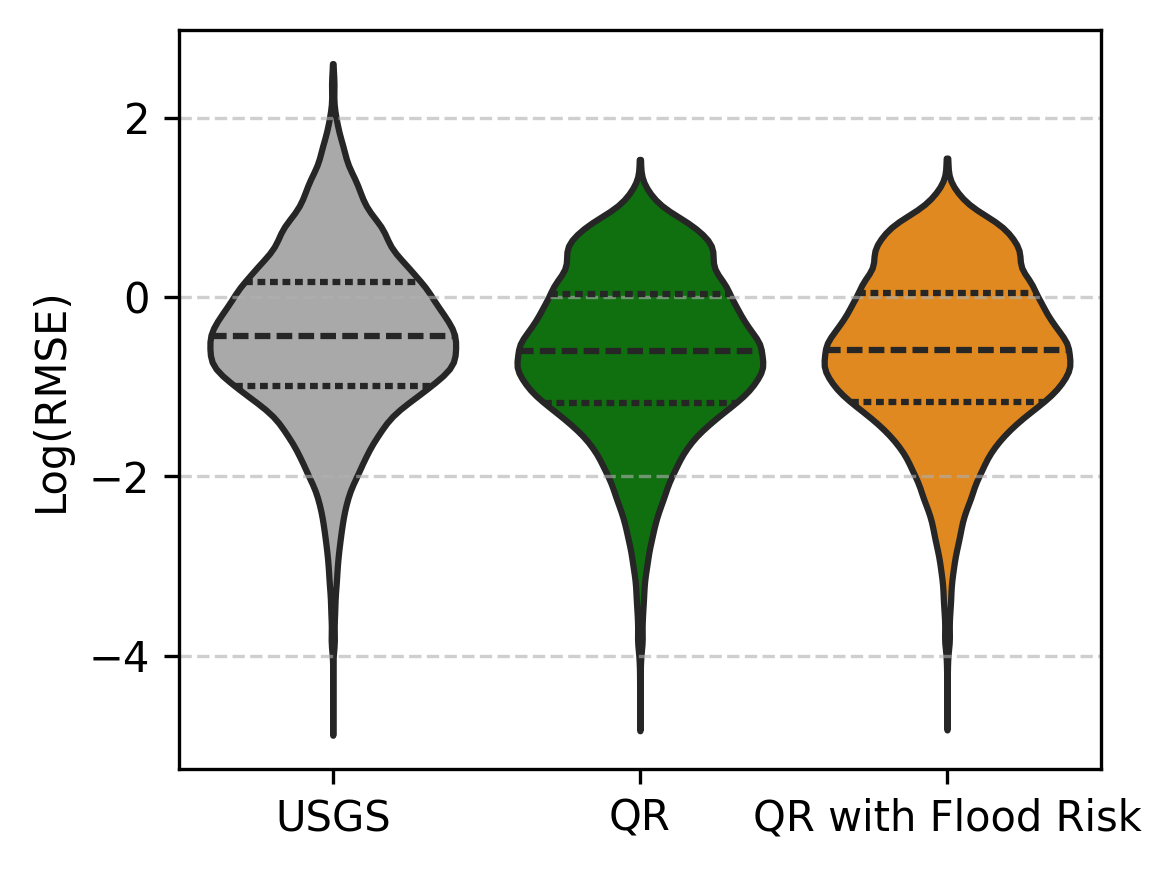

In [16]:
# Filter and log-transform data
filtered_data = [d[(d > 1e-5) & (d < 1e3)] for d in data]
log_data = [np.log10(d) for d in filtered_data]

plt.figure(figsize=(4, 3), dpi=300)
sns.violinplot(
    data=log_data,
    scale='width',   
    inner='quartile',
    linewidth=1.5,
    palette=colors,
    cut=0
)
plt.xticks(ticks=range(len(labels)), labels=labels)
plt.ylabel('Log(RMSE)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()